### Time evolution + Trotter operator generator

#### Heisenberg Chain Hamiltonian

The Heisenberg chain is a fundamental model in condensed matter physics used to describe interacting quantum spins. The Hamiltonian for an anisotropic Heisenberg chain with an external magnetic field is given by:

$H = \sum_{i=1}^{L-1} (J S_i^x S_{i+1}^x + J S_i^y S_{i+1}^y + J S_i^z S_{i+1}^z) + \sum_{i=1}^L (h S_i^z)$

Where:
- $L$ is the number of qubits (spin-1/2 particles).
- $S_i^x, S_i^y, S_i^z$ are the Pauli spin operators for the $i$-th qubit.
- $J$ is the coupling strengths between neighboring spins.
- $h$ is the strength of the external magnetic field acting on each spin.


In [1]:
import numpy as np
from scipy.sparse import csr_matrix, identity, kron
from scipy.sparse.linalg import expm, norm
from scipy.constants import pi
# from scipy.sparse.linalg import norm

# Define Pauli matrices (as sparse matrices for efficiency)
sigma_x = csr_matrix(np.array([[0, 1], [1, 0]], dtype=complex))
sigma_y = csr_matrix(np.array([[0, -1j], [1j, 0]], dtype=complex))
sigma_z = csr_matrix(np.array([[1, 0], [0, -1]], dtype=complex))
identity_2x2 = csr_matrix(np.array([[1, 0], [0, 1]], dtype=complex))

In [2]:
# Global model parameters
n = 1        # Number of qubits (L)
J = 1.0      # Isotropic exchange coupling strength
h = 0.5         # Strength of the external magnetic field in the z-direction

t = 2.0 # Target simulation time

In [3]:
# Helper function to create an operator acting on specific qubit(s)
def get_local_operator(op, num_qubits, *qubit_indices):
    """
    Generates a global operator (tensor product) acting on specific qubits.

    Args:
        op (csr_matrix): The local operator (e.g., Pauli matrix) to apply.
        num_qubits (int): Total number of qubits in the system.
        identity_op (csr_matrix): The 2x2 identity matrix.
        qubit_indices (tuple): Indices of the qubits where `op` acts.

    Returns:
        csr_matrix: The global operator as a sparse matrix.
    """
    operators = [identity_2x2] * num_qubits
    for idx in qubit_indices:
        if not (0 <= idx < num_qubits):
            raise IndexError(f"Qubit index {idx} out of bounds for {num_qubits} qubits.")
        operators[idx] = op

    # Perform Kronecker product iteratively
    current_op = operators[0]
    for i in range(1, num_qubits):
        current_op = kron(current_op, operators[i])
    return current_op

In [4]:
def get_individual_hamiltonian_terms(
    num_qubits: int,
    J: float,
    h: float
) -> list[csr_matrix]:
    """
    Decomposes the isotropic Heisenberg chain Hamiltonian into a list of individual
    Pauli string terms.

    Args:
        num_qubits (int): The number of qubits (L).
        J (float): Isotropic exchange coupling strength for x, y, and z terms.
        h (float): Strength of the external magnetic field in the z-direction.

    Returns:
        list[csr_matrix]: A list of sparse matrices, each representing one term
                          in the Hamiltonian.
    """
    if num_qubits < 1:
        raise ValueError("Number of qubits must be at least 1.")

    terms = []

    # Interaction terms (J S_i^x S_{i+1}^x + J S_i^y S_{i+1}^y + J S_i^z S_{i+1}^z)
    # Open boundary conditions: sum from i=0 to num_qubits-2 (L-1 interactions)
    for i in range(num_qubits - 1):
        terms.append((J) * get_local_operator(sigma_x, num_qubits, i, i + 1))
        terms.append((J) * get_local_operator(sigma_y, num_qubits, i, i + 1))
        terms.append((J) * get_local_operator(sigma_z, num_qubits, i, i + 1))

    # Magnetic field terms (h S_i^z)
    # Sum from i=0 to num_qubits-1 (L terms)
    for i in range(num_qubits):
        terms.append((h) * get_local_operator(sigma_z, num_qubits, i))

    return terms

### Generate Trotterized operator

In [5]:
def generate_trotter_second_order(
    num_qubits: int,
    J: float,
    h: float,
    t: float,
    trotter_dt: float
) -> csr_matrix:
    """
    Generates the second-order Trotterized time evolution operator for the
    isotropic Heisenberg chain with a z-direction external magnetic field,
    by decomposing the Hamiltonian into individual Pauli string terms.

    The Trotter formula used is U(dt) = Product_{k=1..M} exp(-i H_k dt/2) * Product_{k=M..1} exp(-i H_k dt/2).

    Args:
        num_qubits (int): The number of qubits (L).
        J (float): Isotropic exchange coupling strength.
        h (float): Strength of the external magnetic field in the z-direction.
        trotter_dt (float): The Trotter time step.

    Returns:
        csr_matrix: The second-order Trotterized time evolution operator.
    """
    # Ensure number of Trotter steps is integer
    num_trotter_steps = t / trotter_dt
    if not num_trotter_steps.is_integer():
        raise ValueError("Total time 't' must be an integer multiple of 'trotter_dt'.")

    # Get all individual Pauli string terms from the Hamiltonian
    list_of_terms = get_individual_hamiltonian_terms(num_qubits, J, h)

    dim = 2**num_qubits
    U_forward = identity(dim, dtype=complex, format='csr')
    U_backward = identity(dim, dtype=complex, format='csr')

    # First half of the Trotter expansion (forward product)
    for term in list_of_terms:
        U_forward = U_forward @ expm(-0.5j * term * trotter_dt)

    # Second half of the Trotter expansion (reverse product)
    for term in reversed(list_of_terms):
        U_backward = U_backward @ expm(-0.5j * term * trotter_dt)

    # Combine for the full second-order Trotter step and return full Trotter operator
    U_single_step = U_forward @ U_backward
    U_trotter = U_single_step**(int(num_trotter_steps))
    return U_trotter

In [6]:
def generate_trotter_operators_for_dt_range(
    num_qubits: int,
    J: float,
    h: float,
    t: float,
    trotter_dt_range: list[float]
) -> list[csr_matrix]:
    """
    Generates a *list* of second-order Trotterized time evolution operators
    for a given range of trotter_dt values.

    Args:
        num_qubits (int): The number of qubits (L).
        J (float): Isotropic exchange coupling strength.
        h (float): Strength of the external magnetic field in the z-direction.
        t (float): Total simulation time.
        trotter_dt_range (list[float]): A list of Trotter time steps to evaluate.

    Returns:
        list[csr_matrix]: A list of csr_matrix objects, each representing
                          a second-order Trotterized time evolution operator
                          for a specific trotter_dt from the input range.
    """
    trotter_operators = []
    for trotter_dt in trotter_dt_range:
        # Ensure t is an integer multiple of trotter_dt for each calculation
        # if not (t / trotter_dt).is_integer():
        #    print(f"Warning: Total time {t} is not an integer multiple of trotter_dt = {trotter_dt}. Skipping this dt.")
        #    continue

        operator = generate_trotter_second_order(
            num_qubits, J, h, t, trotter_dt
        )
        trotter_operators.append(operator)
    return trotter_operators

#### Generate exact time evolution operator

In [7]:
def generate_heisenberg_hamiltonian(
    num_qubits: int,
    J: float,
    h: float
) -> csr_matrix:
    """
    Generates the Hamiltonian matrix for an isotropic Heisenberg chain
    with a z-direction external magnetic field (open boundary conditions).

    The Hamiltonian is given by:
    $H = \sum_{i=1}^{L-1} (J S_i^x S_{i+1}^x + J S_i^y S_{i+1}^y + J S_i^z S_{i+1}^z) + \sum_{i=1}^L (h S_i^z)$

    Args:
        num_qubits (int): The number of qubits (L).
        J (float): Isotropic exchange coupling strength for x, y, and z terms.
        h (float): Strength of the external magnetic field in the z-direction.

    Returns:
        csr_matrix: The Hamiltonian matrix in sparse format.
    """

    if num_qubits < 1:
        raise ValueError("Number of qubits must be at least 1.")

    dim = 2**num_qubits
    H = csr_matrix((dim, dim), dtype=complex)
    I = identity_2x2

    def get_local_operator(op, *qubit_indices):
        operators = [I] * num_qubits
        for idx in qubit_indices:
            if not (0 <= idx < num_qubits):
                raise IndexError(f"Qubit index {idx} out of bounds for {num_qubits} qubits.")
            operators[idx] = op
        current_op = operators[0]
        for i in range(1, num_qubits):
            current_op = kron(current_op, operators[i])
        return current_op

    # Interaction terms (J S_i^x S_{i+1}^x + J S_i^y S_{i+1}^y + J S_i^z S_{i+1}^z)
    # Open boundary conditions: sum from i=0 to num_qubits-2 (L-1 interactions)
    for i in range(num_qubits - 1):
        H += (J) * get_local_operator(sigma_x, i, i + 1)
        H += (J) * get_local_operator(sigma_y, i, i + 1)
        H += (J) * get_local_operator(sigma_z, i, i + 1)

    # Magnetic field terms (h S_i^z)
    # Sum from i=0 to num_qubits-1 (L terms)
    for i in range(num_qubits):
        H += (h) * get_local_operator(sigma_z, i)

    return H

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2615/3651459393.py:11: SyntaxWarning: invalid escape sequence '\s'
  $H = \sum_{i=1}^{L-1} (J S_i^x S_{i+1}^x + J S_i^y S_{i+1}^y + J S_i^z S_{i+1}^z) + \sum_{i=1}^L (h S_i^z)$


#### Test for an example:

Let's generate the Hamiltonian for some specific test parameters.

In [8]:
# test model parameters
n_test = 3        # Number of qubits (L)
J_test = 1.0      # exchange coupling strength
h_test = 1.0         # Strength of the external magnetic field in the z-direction

t_test = 2.0 # Target simulation time
dt_test = 0.5

In [9]:
# Generate the Hamiltonian matrix using test parameters
heisenberg_hamiltonian_test = generate_heisenberg_hamiltonian(
    n_test, J_test, h_test
)

print(f"Hamiltonian for {n_test} qubits (new model):")
print(heisenberg_hamiltonian_test)
print(f"\nShape of the Hamiltonian matrix: {heisenberg_hamiltonian_test.shape}")
print(f"Number of non-zero elements: {heisenberg_hamiltonian_test.nnz}")

Hamiltonian for 3 qubits (new model):
<Compressed Sparse Row sparse matrix of dtype 'complex128'
	with 16 stored elements and shape (8, 8)>
  Coords	Values
  (0, 0)	(5+0j)
  (1, 1)	(1+0j)
  (1, 2)	(2+0j)
  (2, 1)	(2+0j)
  (2, 2)	(-1+0j)
  (2, 4)	(2+0j)
  (3, 3)	(-1+0j)
  (3, 5)	(2+0j)
  (4, 2)	(2+0j)
  (4, 4)	(1+0j)
  (5, 3)	(2+0j)
  (5, 5)	(-3+0j)
  (5, 6)	(2+0j)
  (6, 5)	(2+0j)
  (6, 6)	(-1+0j)
  (7, 7)	(-1+0j)

Shape of the Hamiltonian matrix: (8, 8)
Number of non-zero elements: 16


In [10]:
# Calculate the time evolution operator U = exp(-i * H * t)
# Note: heisenberg_hamiltonian_new_model is already defined from previous steps
exact = expm(-1j * heisenberg_hamiltonian_test * t_test)

print(f"Time evolution operator for test time t = {t_test}:")
print(exact)
print(f"\nShape of the time evolution operator: {exact.shape}")
print(f"Number of non-zero elements: {exact.nnz}")

# You can also convert to a dense matrix to inspect its values (caution for large systems)
print("\nDense representation of the time evolution operator:")
print(exact.todense())

Time evolution operator for test time t = 2.0:
<Compressed Sparse Row sparse matrix of dtype 'complex128'
	with 20 stored elements and shape (8, 8)>
  Coords	Values
  (0, 0)	(-0.8390715290764521+0.5440211108893693j)
  (1, 1)	(0.27201172505161153-0.4080794637130199j)
  (1, 2)	(8.326672684688674e-17+0.18627699879928394j)
  (1, 4)	(0.6881585615987542+0.501217963112662j)
  (2, 1)	(1.1102230246251565e-16+0.18627699879928386j)
  (2, 2)	(0.9601702866503657-0.09313849939964172j)
  (2, 4)	(1.8735013540549517e-16+0.1862769987992838j)
  (3, 3)	(-0.4866342853020277+0.06087938598938569j)
  (3, 5)	(0.14097489750977021-0.1217587719787706j)
  (3, 6)	(-0.07048744875488516-0.8484180408362967j)
  (4, 1)	(0.6881585615987541+0.5012179631126619j)
  (4, 2)	(1.3183898417423734e-16+0.18627699879928375j)
  (4, 4)	(0.27201172505161175-0.40807946371301984j)
  (5, 3)	(0.14097489750977013-0.12175877197877068j)
  (5, 5)	(-0.6980966315666833-0.6657798828681406j)
  (5, 6)	(0.1409748975097703-0.12175877197877073j)
  (6

/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


In [11]:
# Generate the second-order Trotter operator using the global parameters
trotter_operator = generate_trotter_second_order(
    n_test, J_test, h_test, t_test, dt_test
)

print(f"Second-order Trotter operator for {n_test} qubits, J={J_test}, h={h_test}, t={t_test}, dt={dt_test} (using individual Pauli string decomposition):")
print(trotter_operator)
print(f"\nShape of the Trotter operator: {trotter_operator.shape}")
print(f"Number of non-zero elements: {trotter_operator.nnz}")

/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  return spsolve(Q, P)


Second-order Trotter operator for 3 qubits, J=1.0, h=1.0, t=2.0, dt=0.5 (using individual Pauli string decomposition):
<Compressed Sparse Row sparse matrix of dtype 'complex128'
	with 29 stored elements and shape (8, 8)>
  Coords	Values
  (0, 0)	(-0.8390715290764461+0.5440211108893644j)
  (0, 6)	(-6.7091782923898e-18-5.071089228588212e-18j)
  (0, 3)	(-6.61794210136883e-18-5.7426017815881786e-18j)
  (0, 5)	(-1.8266314527961427e-18-1.262328393233637e-17j)
  (1, 2)	(0.054831970813647726+0.3182671522895342j)
  (1, 4)	(0.38195675378942007+0.46797828043686507j)
  (1, 1)	(0.5233815620472888-0.5068299345274762j)
  (1, 7)	(1.9632003256216033e-17-2.908505090929871e-17j)
  (2, 2)	(0.7753170908093872-0.3915297365777489j)
  (2, 4)	(0.1300212250273218+0.35267808248713794j)
  (2, 1)	(0.0548319708136478+0.31826715228953417j)
  (2, 7)	(-1.2741139074065087e-17+1.2665794100237507e-18j)
  (3, 0)	(-2.7712948969309164e-18+5.9933511152711735e-18j)
  (3, 6)	(0.10450353482430508-0.5949568420778285j)
  (3, 3)	(

S: Verified prints correct exact time evolution operator and Trotterized operator for J=1 h=1 n=2,n=3 with Gemini (note n=2 is special and Trotterized operator exactly equals exact operator).



### Error evaluator

Here we evaluate error between an input matrix with an exact time evolution operator. We will test error via operator norm.

Let's calculate the error between the `exact` time evolution operator and the `trotter_operator`.

In [12]:
def op_norm_error(
    matrix_1: csr_matrix,
    matrix_2: csr_matrix,
) -> float:
    """
    Computes the operator of the difference between two matrices (given in sparse format).

    Args:
        matrix_1 (csr_matrix): The first sparse matrix.
        matrix_2 (csr_matrix): The second sparse matrix.

    Returns:
        float: The operator norm of their difference.
    """
    # Ensure matrices have the same shape for subtraction
    if matrix_1.shape != matrix_2.shape:
        raise ValueError("Matrices must have the same shape for comparison.")

    # Calculate the difference between the two matrices
    diff_matrix = matrix_1 - matrix_2

    # Compute the operator norm (2-norm) of the difference
    error = norm(diff_matrix, 2)
    return error

In [13]:
# test: calculate the error for test Trotter operator
error_value = op_norm_error(exact, trotter_operator)

print(f"Operator norm error is: {error_value}")

Operator norm error is: 0.531362615860051


S: verified for above examples, n=2 and n=3.

In [14]:
# Define a range of trotter_dt values to test
trotter_dt_values = [0.1, 0.2, 0.5, 1.0]

# Generate a list of Trotter operators using the new function
trotter_operators_list = generate_trotter_operators_for_dt_range(
    n_test, J_test, h_test, t_test, trotter_dt_values
)

print(f"Generated {len(trotter_operators_list)} Trotter operators for dt values: {trotter_dt_values}")

# Optionally, you can inspect each operator in the list
for i, op in enumerate(trotter_operators_list):
    print(f"\nOperator for dt = {trotter_dt_values[i]}:")
    print(op)

Generated 4 Trotter operators for dt values: [0.1, 0.2, 0.5, 1.0]

Operator for dt = 0.1:
<Compressed Sparse Row sparse matrix of dtype 'complex128'
	with 32 stored elements and shape (8, 8)>
  Coords	Values
  (0, 0)	(-0.8390715290764829+0.5440211108893874j)
  (0, 6)	(-2.1323612539925024e-18+1.9511431791643875e-17j)
  (0, 3)	(-2.9807012638035675e-18+2.0411899413485863e-17j)
  (0, 5)	(-4.572622004215587e-18+1.2282085560007277e-17j)
  (1, 2)	(-0.001445933459036128+0.19112914061811648j)
  (1, 4)	(0.6780190157097897+0.5020914075282596j)
  (1, 1)	(0.28359720439964387-0.41380504994744177j)
  (1, 7)	(6.3515184519810806e-18-3.7092503525296066e-17j)
  (2, 2)	(0.9562901227315393-0.1059420541081806j)
  (2, 4)	(0.005326097377894202+0.1942284116889993j)
  (2, 1)	(-0.0014459334590361229+0.19112914061811656j)
  (2, 7)	(-2.4778730250750744e-17+1.4650052733406308e-17j)
  (3, 3)	(-0.49645923924505425+0.06300486782779087j)
  (3, 5)	(0.14351117705077093-0.1309869660768293j)
  (3, 0)	(-5.802667031807175e-1

In [15]:
# test
error_list=[]
for m in trotter_operators_list:
    error = op_norm_error(m, exact)
    error_list.append(error)
print(f"Errors are: {error_list}")
print(error_list)

Errors are: [np.float64(0.021078886447026036), np.float64(0.08465856633788509), np.float64(0.531362615860051), np.float64(1.623381564277231)]
[np.float64(0.021078886447026036), np.float64(0.08465856633788509), np.float64(0.531362615860051), np.float64(1.623381564277231)]


### Generate Trotter data and plot

In [16]:
import matplotlib.pyplot as plt

In [17]:
# Global model parameters
n = 4        # Number of qubits (L). S: choose small value for prototyping. Eventually n=8 is not unreasonable. Maybe n=10 possible at a push.
J = 1.0      # Isotropic exchange coupling strength
h = 0.5         # Strength of the external magnetic field in the z-direction

t = 2.0 # Target simulation time

# Data parameters
trotter_step_counts=list(range(10,31)) # range of Trotter step number (our proxy for gate depth)
trotter_step_sizes=[t/step for step in trotter_step_counts] # Trotter step sizes

In [18]:
trotter_operators_list = generate_trotter_operators_for_dt_range(
    n, J, h, t, trotter_step_sizes
)

In [19]:
# Generate exact evolution operator
heisenberg_hamiltonian = generate_heisenberg_hamiltonian(n, J, h)
exact_operator = expm(-1j * heisenberg_hamiltonian * t)

In [20]:
# List of operator norm errors for above generated Trotter errors
error_list=[]
for m in trotter_operators_list:
    error = op_norm_error(m, exact_operator)
    error_list.append(error)
print(f"Errors are: {error_list}")

Errors are: [np.float64(0.21064445288427291), np.float64(0.17445719852217464), np.float64(0.14681548809701153), np.float64(0.1252378254747221), np.float64(0.10807793472252887), np.float64(0.09421049584996251), np.float64(0.08284591639339323), np.float64(0.07341730443158741), np.float64(0.06550932293994467), np.float64(0.05881214554172645), np.float64(0.05309090836996328), np.float64(0.04816498422649621), np.float64(0.0438936377707159), np.float64(0.04016591295720322), np.float64(0.03689338656356219), np.float64(0.034004896324703805), np.float64(0.031442653809854525), np.float64(0.02915933805173773), np.float64(0.02711590288771398), np.float64(0.025279898723128816), np.float64(0.02362418499334181)]


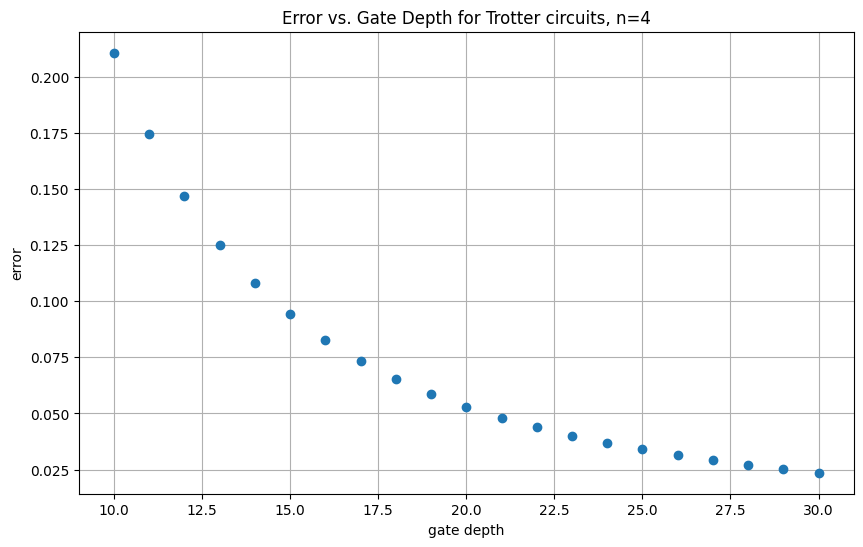

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(trotter_step_counts, error_list, marker='o', linestyle='none')
plt.xlabel('gate depth')
plt.ylabel('error')
plt.title(f'Error vs. Gate Depth for Trotter circuits, n={n}')
plt.grid(True)
plt.show()
#S: maybe we change to log plot, option open for that

### Generate extrapolated data and plot.

We want to take extrapolation schedules from prev. data (well-conditioned and brute force) to generate extrapolated trotter operators. Then look at error. Importantly, the number of Trotter steps should fall within whatever trotter_step_counts is defined to be above. Thus, s should be chosen in a bespoke way so that the max number of Trotter steps (q_max/s) falls within the range of trotter_step_counts. For a given extrapolation scheme, we want to plot all data points that can fit within the range. For instance, if the range is [10,20] and I have an extrapolation scheme of q_max=5, I want to generate extrapolated Trotter operators for 1/s=2,3,4 and this would give me three data points to add to above plot. We also want colors as before for sample overhead, so these 3 data points should have the same color corresponding to their (b_norm)^2

recall trotter step size is s*t (t is target simulation time)

see above trotter_operators_list which already gives you a list of Trotter operators for p=2 for a range of Trotter step sizes

In [22]:
from matplotlib.colors import LogNorm

# Use p=2 schedules to match the second-order Trotter operators generated above.
p_order = 2

# Existing p=2 Trotter operators keyed by integer step count N,
# where U_T(N) = [P_2(t/N)]^N and dt = t/N.
step_to_trotter = {int(N): op for N, op in zip(trotter_step_counts, trotter_operators_list)}
step_min, step_max = min(trotter_step_counts), max(trotter_step_counts)

In [23]:
# A small, hand-picked set of Richardson schemes for p=2.
# Each entry encodes: mode ("wc" well-conditioned, "opt" brute-force),
# the integer refinement grid q_k, the extrapolation coefficients b_k,
# and the sample overhead ‖b‖₁² used for coloring.
# These values are copied from the original overhead parameter sidecar
# for representative ε values.
schemes = [
    {
        "mode": "wc",
        "q_grid": (10, 4),
        "b": np.array([1.6666666666666667, -0.6666666666666667]),
        "bnorm_sq": 1.907,  # ≈ (1.6667 + 0.6667)^2 / some rounding
    },
    {
        "mode": "wc",
        "q_grid": (21, 8, 5),
        "b": np.array([2.1201923076923075, -1.6410256410256405, 0.520833333333333]),
        "bnorm_sq": 2.425,
    },
    {
        "mode": "opt",
        "q_grid": (3, 6, 7),
        "b": np.array([3.089036670832427, -7.024197680170341, 13.017119429498718,
                        -15.83730224343273, 9.780853805548473, -2.9780941526142586,
                        0.952584170337711]),
        "bnorm_sq": 70.3,
    },
    {
        "mode": "opt",
        "q_grid": (1, 3, 4, 5),
        "b": np.array([2.5906234347285877, -3.680529996319486, 3.7565217391304566,
                        -2.0287569573284, 0.3621417797888417]),
        "bnorm_sq": 93.5,
    },
]

Using hard-coded p=2 Richardson schemes (wc + opt)
Trotter step window: [10, 30]


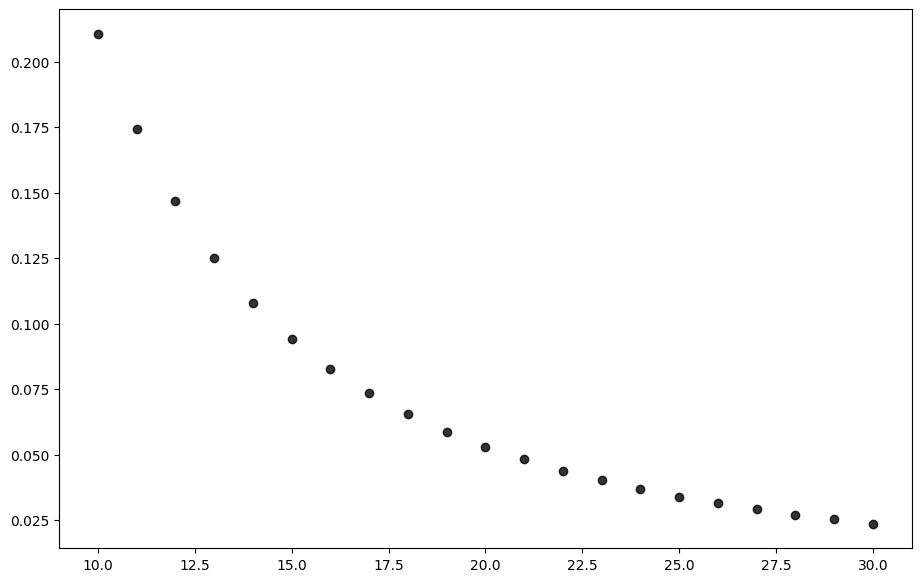

In [24]:
print(f"Using hard-coded p={p_order} Richardson schemes (wc + opt)")
print(f"Trotter step window: [{step_min}, {step_max}]")

plt.figure(figsize=(11, 7))
plt.plot(trotter_step_counts, error_list, marker='o', linestyle='none', color='black', alpha=0.8, label='Trotter (p=2)')

Schemes contributing points: 2
Total Richardson points plotted: 2


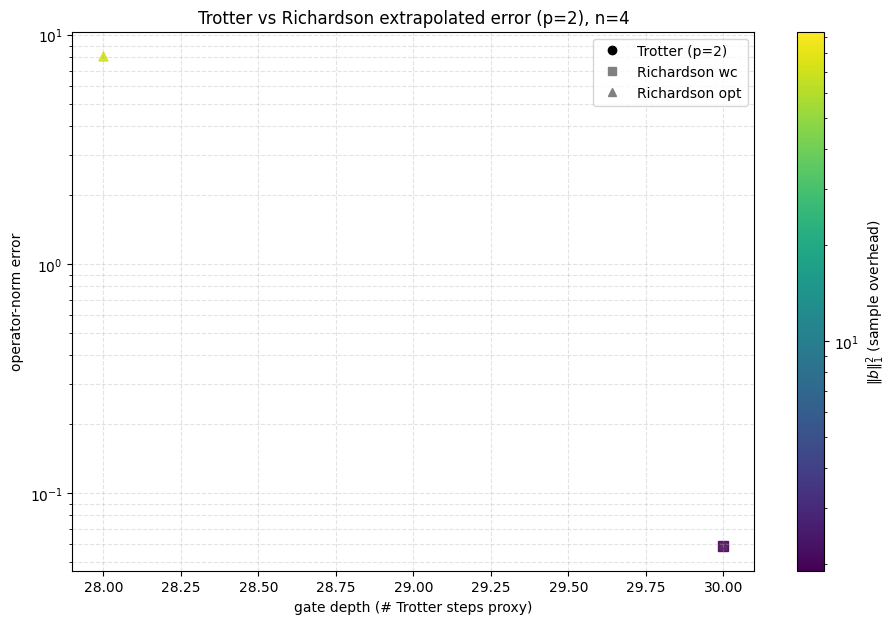

In [28]:
num_points = 0
num_schemes_with_points = 0

# Defensive fallbacks for stale/partial execution in notebooks.
if "fig" not in locals() or "ax" not in locals():
    fig, ax = plt.subplots(figsize=(11, 7))

if "color_norm" not in locals():
    _bn = [m["bnorm_sq"] for m in schemes]
    color_norm = LogNorm(vmin=max(min(_bn), 1e-12), vmax=max(_bn))

for meta in schemes:
    q_grid = meta["q_grid"]
    b = meta["b"]

    # We need all term step counts N_k = q_k / s to lie inside the existing Trotter range.
    # Let r = 1/s (integer), then N_k = q_k * r.
    r_min = max(int(np.ceil(step_min / q)) for q in q_grid)
    r_max = min(int(np.floor(step_max / q)) for q in q_grid)
    if r_min > r_max:
        continue

    x_vals = []
    y_vals = []
    for r in range(r_min, r_max + 1):
        # Build Richardson extrapolated operator:
        # U_R(r) = sum_k b_k * U_T(q_k * r)
        U_r = csr_matrix(exact_operator.shape, dtype=complex)
        N_values = []

        for coeff, q in zip(b, q_grid):
            N_k = int(q * r)
            N_values.append(N_k)
            U_r = U_r + coeff * step_to_trotter[N_k]

        # Plot at largest N_k (dominant gate-depth proxy for this extrapolated point).
        x_vals.append(max(N_values))
        y_vals.append(float(op_norm_error(U_r, exact_operator)))

    if not x_vals:
        continue

    num_schemes_with_points += 1
    num_points += len(x_vals)

    marker = 's' if meta["mode"] == "wc" else '^'
    color = plt.cm.viridis(color_norm(meta["bnorm_sq"]))
    ax.scatter(x_vals, y_vals, color=color, marker=marker, s=42, alpha=0.85)

print(f"Schemes contributing points: {num_schemes_with_points}")
print(f"Total Richardson points plotted: {num_points}")

ax.set_yscale('log')
ax.set_xlabel('gate depth (# Trotter steps proxy)')
ax.set_ylabel('operator-norm error')
ax.set_title(f'Trotter vs Richardson extrapolated error (p={p_order}), n={n}')
ax.grid(True, which='both', ls='--', alpha=0.35)

# Legend (mode encoding) + colorbar (sample overhead encoding).
handles = [
    plt.Line2D([], [], marker='o', linestyle='none', color='black', label='Trotter (p=2)'),
    plt.Line2D([], [], marker='s', linestyle='none', color='gray', label='Richardson wc'),
    plt.Line2D([], [], marker='^', linestyle='none', color='gray', label='Richardson opt'),
]
ax.legend(handles=handles, loc='best')

sm = plt.cm.ScalarMappable(norm=color_norm, cmap=plt.cm.viridis)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r'$\|b\|_1^2$ (sample overhead)')

plt.show()

In [ ]:
from matplotlib.colors import LogNorm

# Final extrapolation section (self-contained):
# - uses hard-coded schedules from previous overhead sidecar values
# - includes both wc and opt schedule families
# - chooses integer 1/s values via q_max gate-depth rule
# - computes missing Trotter operators on-demand

p_order = 2

# Existing p=2 Trotter operators from earlier cells, keyed by integer step count N.
step_to_trotter = {int(N): op for N, op in zip(trotter_step_counts, trotter_operators_list)}
step_min, step_max = min(trotter_step_counts), max(trotter_step_counts)

# Representative schedules from prior data (wc + opt).
active_schemes = [
    {"mode": "wc",  "label": "wc q=[3]",         "q_grid": (3,),          "b": np.array([1.0]),                                                 "bnorm_sq": 1.0},
    {"mode": "wc",  "label": "wc q=[10,4]",      "q_grid": (10, 4),       "b": np.array([1.1904761904761905, -0.19047619047619052]),            "bnorm_sq": 1.907},
    {"mode": "opt", "label": "opt q=[2,7,10]",   "q_grid": (2, 7, 10),    "b": np.array([0.10000000000000053, -3.266666666666671, 4.1666666666666705]), "bnorm_sq": 56.75},
    {"mode": "opt", "label": "opt q=[1,3,6,10]", "q_grid": (1, 3, 6, 10), "b": np.array([-0.011111111111111072, 0.6428571428571401, -3.599999999999993, 3.968253968253964]), "bnorm_sq": 67.6},
]

# Keep only valid schemes.
valid_schemes = []
for s in active_schemes:
    if len(s["q_grid"]) != len(s["b"]):
        print(f"Skipping invalid scheme {s['label']}: len(q_grid) != len(b)")
        continue
    valid_schemes.append(s)

# Cache operators so each N is built once.
operator_cache = dict(step_to_trotter)

def get_trotter_operator_for_steps(N):
    N = int(N)
    if N <= 0:
        raise ValueError("Step count N must be positive")
    if N not in operator_cache:
        dt = t / N
        operator_cache[N] = generate_trotter_second_order(n, J, h, t, dt)
    return operator_cache[N]

fig, ax = plt.subplots(figsize=(11, 7))
ax.plot(trotter_step_counts, error_list, marker='o', linestyle='none', color='black', alpha=0.8, label='Trotter (p=2)')

all_bnorm_sq = [s["bnorm_sq"] for s in valid_schemes]
color_norm = LogNorm(vmin=max(min(all_bnorm_sq), 1e-12), vmax=max(all_bnorm_sq))

num_points = 0
num_schemes_with_points = 0

for meta in valid_schemes:
    q_grid = tuple(int(q) for q in meta["q_grid"])
    b = np.asarray(meta["b"], dtype=float)
    q_max = max(q_grid)

    # Requirement-driven range: choose integer r = 1/s so that
    # max Trotter step count q_max * r is within [step_min, step_max].
    r_min = int(np.ceil(step_min / q_max))
    r_max = int(np.floor(step_max / q_max))
    if r_min > r_max:
        continue

    x_vals = []
    y_vals = []

    for r in range(r_min, r_max + 1):
        N_values = [int(q * r) for q in q_grid]

        U_r = csr_matrix(exact_operator.shape, dtype=complex)
        for coeff, N_k in zip(b, N_values):
            U_r = U_r + coeff * get_trotter_operator_for_steps(N_k)

        x_vals.append(max(N_values))
        y_vals.append(float(op_norm_error(U_r, exact_operator)))

    if not x_vals:
        continue

    num_schemes_with_points += 1
    num_points += len(x_vals)

    marker = 's' if meta["mode"] == "wc" else '^'
    color = plt.cm.viridis(color_norm(meta["bnorm_sq"]))
    ax.scatter(x_vals, y_vals, color=color, marker=marker, s=48, alpha=0.9)

print(f"Schemes contributing points: {num_schemes_with_points}")
print(f"Total Richardson points plotted: {num_points}")

ax.set_yscale('log')
ax.set_xlabel('gate depth (# Trotter steps proxy)')
ax.set_ylabel('operator-norm error')
ax.set_title(f'Trotter vs Richardson extrapolated error (p={p_order}), n={n}')
ax.grid(True, which='both', ls='--', alpha=0.35)

handles = [
    plt.Line2D([], [], marker='o', linestyle='none', color='black', label='Trotter (p=2)'),
    plt.Line2D([], [], marker='s', linestyle='none', color='gray', label='Richardson wc'),
    plt.Line2D([], [], marker='^', linestyle='none', color='gray', label='Richardson opt'),
]
ax.legend(handles=handles, loc='best')

sm = plt.cm.ScalarMappable(norm=color_norm, cmap=plt.cm.viridis)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r'$\|b\|_1^2$ (sample overhead)')

plt.show()